<a href="https://colab.research.google.com/github/PriFranca/trading-dados-2018/blob/main/Modulo_2_Trading_com_Dados_1602.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from IPython.display import Image
Image("Logo 11.PNG")

# Parte 1- Primeiros Passos

### (a) Importar pacotes:

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

%matplotlib inline

from IPython.display import Image

from datetime import datetime

import pandas as pd
import numpy as np

import seaborn as sns
# sns.set(style="whitegrid")

### (b) Importar bases:

In [ ]:

dados = pd.read_csv("dados_itub3_tratado.csv")

# pd.read_csv("dados_itub3_tratado.csv",encoding='latin-1',sep=';')

### (c) Principais comandos :

In [ ]:
# Ver o nome de todas variáveis

dados.columns

Index(['Unnamed: 0', 'timestamp', 'open', 'high', 'low', 'close', 'volume'], dtype='object')

In [ ]:
# visualizar tabelas e verificar dimensoes
dados.shape


(680, 7)

In [ ]:
len(dados)

680

In [ ]:
dados.head()

,Unnamed: 0,timestamp,open,high,low,close,volume
0,0,2019-07-24 10:00:00,31.559999,31.559999,31.559999,31.559999,0.0
1,1,2019-07-24 10:05:00,31.570000,31.600000,31.570000,31.600000,1100.0
2,2,2019-07-24 10:10:00,31.620001,31.750000,31.620001,31.709999,3100.0
3,3,2019-07-24 10:15:00,31.700001,31.709999,31.660000,31.680000,3800.0
4,4,2019-07-24 10:20:00,31.670000,31.670000,31.570000,31.590000,8600.0


In [ ]:
dados.tail(5)

,Unnamed: 0,timestamp,open,high,low,close,volume
675,675,2019-08-02 16:40:00,29.969999,30.00,29.959999,30.000000,16200.0
676,676,2019-08-02 16:45:00,29.980000,30.00,29.959999,30.000000,18600.0
677,677,2019-08-02 16:50:00,29.969999,30.00,29.959999,29.959999,21200.0
678,678,2019-08-02 16:55:00,NaN,NaN,NaN,NaN,NaN
679,679,2019-08-02 17:05:00,29.960000,29.96,29.960000,29.960000,16200.0


In [ ]:
#visão geral dos campos

dados.describe()

,Unnamed: 0,open,high,low,close,volume
count,680.000000,659.000000,659.000000,659.000000,659.000000,659.000000
mean,339.500000,30.592914,30.709636,30.517784,30.632913,13708.649469
std,196.443376,1.783583,0.570257,2.143978,1.325296,41201.544455
min,0.000000,0.000000,29.780001,0.000000,0.000000,0.000000
25%,169.750000,30.080000,30.120001,30.030001,30.075000,2700.000000
50%,339.500000,30.709999,30.730000,30.680000,30.700001,6000.000000
75%,509.250000,31.045000,31.080000,31.020000,31.049999,13200.000000
max,679.000000,31.900000,31.900000,31.900000,31.900000,807000.000000


In [ ]:
# contagem de missings

dados.isnull().sum()

Unnamed: 0     0
timestamp      0
open          21
high          21
low           21
close         21
volume        21
dtype: int64

In [ ]:
# tipo das variáveis

dados.dtypes

Unnamed: 0      int64
timestamp      object
open          float64
high          float64
low           float64
close         float64
volume        float64
dtype: object

In [ ]:
# Renomerar nome das colunas

dados2 = dados
dados2.rename(index=str, columns={"open": "abertura", "close": "fechamento"}) # explicar "inplace"


,Unnamed: 0,timestamp,abertura,high,low,fechamento,volume
0,0,2019-07-24 10:00:00,31.559999,31.559999,31.559999,31.559999,0.0
1,1,2019-07-24 10:05:00,31.570000,31.600000,31.570000,31.600000,1100.0
2,2,2019-07-24 10:10:00,31.620001,31.750000,31.620001,31.709999,3100.0
3,3,2019-07-24 10:15:00,31.700001,31.709999,31.660000,31.680000,3800.0
4,4,2019-07-24 10:20:00,31.670000,31.670000,31.570000,31.590000,8600.0
...,...,...,...,...,...,...,...
675,675,2019-08-02 16:40:00,29.969999,30.000000,29.959999,30.000000,16200.0
676,676,2019-08-02 16:45:00,29.980000,30.000000,29.959999,30.000000,18600.0
677,677,2019-08-02 16:50:00,29.969999,30.000000,29.959999,29.959999,21200.0
678,678,2019-08-02 16:55:00,NaN,NaN,NaN,NaN,NaN


In [ ]:
dados3 = dados
dados3.rename(index=str, columns={"open": "abertura", "close": "fechamento"},inplace=True) # explicar "inplace"


# --------------------------------------------------------------------------------------------------------------

# Parte 2  -  Manipulação de variáveis:

Manipulaçao de variaveis

(selecionar colunas, operaçoes entre colunas, criaçao de flags, renomear, filtrar, dropar,tratar missings,apply)

### (a) Selecionar váriaveis e linhas:

In [ ]:
# selecionar 1 variável

time = dados[['timestamp']]
time.head()

,timestamp
0,2019-07-24 10:00:00
1,2019-07-24 10:05:00
2,2019-07-24 10:10:00
3,2019-07-24 10:15:00
4,2019-07-24 10:20:00


In [ ]:
# selecionar N variáveis

dados_selecionados = dados[['timestamp','abertura','high']]
dados_selecionados.head()

,timestamp,abertura,high
0,2019-07-24 10:00:00,31.559999,31.559999
1,2019-07-24 10:05:00,31.570000,31.600000
2,2019-07-24 10:10:00,31.620001,31.750000
3,2019-07-24 10:15:00,31.700001,31.709999
4,2019-07-24 10:20:00,31.670000,31.670000


In [ ]:
# Selecionando colunas pelo index

colunas_selec = dados.iloc[:,2:5] # Estamos selecionando todas as linhas, mas pegamos só as colunas de index 2 até o 5 - [2,5)
colunas_selec.head()

,abertura,high,low
0,31.559999,31.559999,31.559999
1,31.570000,31.600000,31.570000
2,31.620001,31.750000,31.620001
3,31.700001,31.709999,31.660000
4,31.670000,31.670000,31.570000


In [ ]:
# Selecionando linhas

linhas_selec = dados.iloc[3:10,:] # Estamos selecionando todas as colunas,mas pegamos só as linhas entre [3,10)
linhas_selec

,Unnamed: 0,timestamp,abertura,high,low,fechamento,volume
3,3,2019-07-24 10:15:00,31.700001,31.709999,31.660000,31.680000,3800.0
4,4,2019-07-24 10:20:00,31.670000,31.670000,31.570000,31.590000,8600.0
5,5,2019-07-24 10:25:00,31.590000,31.600000,31.559999,31.570000,5800.0
6,6,2019-07-24 10:30:00,31.650000,31.670000,31.620001,31.670000,4900.0
7,7,2019-07-24 10:35:00,31.670000,31.709999,31.670000,31.709999,2800.0
8,8,2019-07-24 10:40:00,31.709999,31.750000,31.709999,31.750000,300.0
9,9,2019-07-24 10:45:00,31.760000,31.760000,31.760000,31.760000,300.0


In [ ]:
# Selecionando linhas e colunas

lin_col_selec = dados.iloc[4:5,1:5]
lin_col_selec

,timestamp,abertura,high,low
4,2019-07-24 10:20:00,31.67,31.67,31.57


### (b) Operações entre colunas:

In [ ]:
dados.head(1)

,Unnamed: 0,timestamp,abertura,high,low,fechamento,volume
0,0,2019-07-24 10:00:00,31.559999,31.559999,31.559999,31.559999,0.0


In [ ]:
# Criar uma nova colunas

dados['dif'] = dados['abertura'] - dados['fechamento']
dados.head()

,Unnamed: 0,timestamp,abertura,high,low,fechamento,volume,dif
0,0,2019-07-24 10:00:00,31.559999,31.559999,31.559999,31.559999,0.0,0.000000
1,1,2019-07-24 10:05:00,31.570000,31.600000,31.570000,31.600000,1100.0,-0.030001
2,2,2019-07-24 10:10:00,31.620001,31.750000,31.620001,31.709999,3100.0,-0.089998
3,3,2019-07-24 10:15:00,31.700001,31.709999,31.660000,31.680000,3800.0,0.020000
4,4,2019-07-24 10:20:00,31.670000,31.670000,31.570000,31.590000,8600.0,0.080000


### (c) Dropar uma coluna

In [ ]:
dados.drop(["Unnamed: 0"], axis =1,inplace=True)
dados.columns

Index(['timestamp', 'abertura', 'high', 'low', 'fechamento', 'volume', 'dif'], dtype='object')

### (d) Ordenar por uma ou mais colunas

In [ ]:
dados_ordenados = dados.sort_values(['abertura','fechamento'], ascending=False)
dados_ordenados.head(5)

,timestamp,abertura,high,low,fechamento,volume,dif
18,2019-07-24 11:30:00,31.900000,31.900000,31.900000,31.900000,2900.0,0.000000
21,2019-07-24 11:45:00,31.900000,31.900000,31.889999,31.889999,800.0,0.010000
22,2019-07-24 11:50:00,31.889999,31.889999,31.889999,31.889999,1600.0,0.000000
17,2019-07-24 11:25:00,31.860001,31.900000,31.860001,31.900000,200.0,-0.039999
23,2019-07-24 11:55:00,31.860001,31.860001,31.820000,31.850000,5800.0,0.010000


### (e) Tratamento de *missings*:

In [ ]:
# Remove todas as linhas que possuem ALGUM valor faltante
dados.dropna()

# Linhas que possuem TODOS os valores faltantes
dados.dropna(how='all')

# Substituir pela média
dados['abertura'].fillna(dados['abertura'].mean(), inplace=False)

# Preencher com uma constante
dados['abertura'].fillna(1, inplace=False)
dados.head(1)

,timestamp,abertura,high,low,fechamento,volume,dif
0,2019-07-24 10:00:00,31.559999,31.559999,31.559999,31.559999,0.0,0.0


In [ ]:
# Substituindo o missing pela das colunas open e close pela media

dados['abertura'].fillna(dados['abertura'].mean(), inplace=True)
dados['fechamento'].fillna(dados['fechamento'].mean(), inplace=True)

dados['high'].fillna(dados['high'].mean(), inplace=True)
dados['low'].fillna(dados['low'].mean(), inplace=True)





### (f) Criar *Flags* usando condições:

In [ ]:
# Vamos comparar abertura com fechamento de cada candle para decidir de foi um candle de alta ou baixa

dados['tipo_candle'] = np.where((dados['abertura']> dados['fechamento']), 'baixa', 'alta')
dados.head()

,timestamp,abertura,high,low,fechamento,volume,dif,tipo_candle
0,2019-07-24 10:00:00,31.559999,31.559999,31.559999,31.559999,0.0,0.000000,alta
1,2019-07-24 10:05:00,31.570000,31.600000,31.570000,31.600000,1100.0,-0.030001,alta
2,2019-07-24 10:10:00,31.620001,31.750000,31.620001,31.709999,3100.0,-0.089998,alta
3,2019-07-24 10:15:00,31.700001,31.709999,31.660000,31.680000,3800.0,0.020000,baixa
4,2019-07-24 10:20:00,31.670000,31.670000,31.570000,31.590000,8600.0,0.080000,baixa


### (g) Filtrar por categorias de alguma coluna

In [ ]:
dados_filtrados = dados.loc[(dados['tipo_candle']=='alta')]
dados_filtrados.head(5)

,timestamp,abertura,high,low,fechamento,volume,dif,tipo_candle
0,2019-07-24 10:00:00,31.559999,31.559999,31.559999,31.559999,0.0,0.000000,alta
1,2019-07-24 10:05:00,31.570000,31.600000,31.570000,31.600000,1100.0,-0.030001,alta
2,2019-07-24 10:10:00,31.620001,31.750000,31.620001,31.709999,3100.0,-0.089998,alta
6,2019-07-24 10:30:00,31.650000,31.670000,31.620001,31.670000,4900.0,-0.020000,alta
7,2019-07-24 10:35:00,31.670000,31.709999,31.670000,31.709999,2800.0,-0.039999,alta


In [ ]:
# Conta a quantidade de elementos por categoria de uma variável

frequencia = pd.value_counts(dados['tipo_candle'])
frequencia

alta     380
baixa    300
Name: tipo_candle, dtype: int64

### (h) Uso do GROUP BY para sumarização

In [ ]:
dados_agrupados = dados.groupby(['tipo_candle']).mean()
dados_agrupados

,abertura,high,low,fechamento,volume,dif
tipo_candle,,,,,,
alta,30.501845,30.701059,30.488220,30.686898,10805.013928,-0.193538
baixa,30.708267,30.720500,30.555233,30.564533,17183.333333,0.143733


# --------------------------------------------------------------------------------------------------------------


# Parte 3 - Operaçoes entre tabelas

### (a) Carregar bases

In [ ]:
# Concatenar
# merge ( inner ,left, all )

dados_itub = pd.read_csv("dados_itub3_tratado.csv")
dados_itub['flag'] = 'itub'
dados_itub.head(3).T

,0,1,2
Unnamed: 0,0,1,2
timestamp,2019-07-24 10:00:00,2019-07-24 10:05:00,2019-07-24 10:10:00
open,31.56,31.57,31.62
high,31.56,31.6,31.75
low,31.56,31.57,31.62
close,31.56,31.6,31.71
volume,0,1100,3100
flag,itub,itub,itub


In [ ]:
dados_petr = pd.read_csv("dados_petr4_tratado.csv")
dados_petr['flag'] = 'petr'
dados_petr.head(3)

,Unnamed: 0,timestamp,open,high,low,close,volume,flag
0,0,2019-07-24 13:45:00,27.530001,27.559999,27.52,27.540001,0.0,petr
1,1,2019-07-24 13:50:00,27.540001,27.549999,27.51,27.530001,145100.0,petr
2,2,2019-07-24 13:55:00,27.520000,27.530001,27.51,27.520000,83900.0,petr


### (b) Concatenar Bases ( Empilhar)

In [ ]:
dados_empilhados = pd.concat([ dados_itub , dados_petr ])

In [ ]:
dados_empilhados.tail()

,Unnamed: 0,timestamp,open,high,low,close,volume,flag
630,630,2019-08-02 16:40:00,26.590000,26.60,26.549999,26.600000,748300.0,petr
631,631,2019-08-02 16:45:00,26.590000,26.67,26.580000,26.620001,1304800.0,petr
632,632,2019-08-02 16:50:00,26.620001,26.65,26.559999,26.639999,625200.0,petr
633,633,2019-08-02 16:55:00,NaN,NaN,NaN,NaN,NaN,petr
634,634,2019-08-02 17:05:00,26.520000,26.52,26.520000,26.520000,2294700.0,petr


In [ ]:
dados_empilhados.head()

,Unnamed: 0,timestamp,open,high,low,close,volume,flag
0,0,2019-07-24 10:00:00,31.559999,31.559999,31.559999,31.559999,0.0,itub
1,1,2019-07-24 10:05:00,31.570000,31.600000,31.570000,31.600000,1100.0,itub
2,2,2019-07-24 10:10:00,31.620001,31.750000,31.620001,31.709999,3100.0,itub
3,3,2019-07-24 10:15:00,31.700001,31.709999,31.660000,31.680000,3800.0,itub
4,4,2019-07-24 10:20:00,31.670000,31.670000,31.570000,31.590000,8600.0,itub


In [ ]:
dados_empilhados.tail()

,Unnamed: 0,timestamp,open,high,low,close,volume,flag
630,630,2019-08-02 16:40:00,26.590000,26.60,26.549999,26.600000,748300.0,petr
631,631,2019-08-02 16:45:00,26.590000,26.67,26.580000,26.620001,1304800.0,petr
632,632,2019-08-02 16:50:00,26.620001,26.65,26.559999,26.639999,625200.0,petr
633,633,2019-08-02 16:55:00,NaN,NaN,NaN,NaN,NaN,petr
634,634,2019-08-02 17:05:00,26.520000,26.52,26.520000,26.520000,2294700.0,petr


### (c) Fazer *Join* entre duas ou mais bases

In [ ]:
Image("tipos_join.png")

In [ ]:
# Vamos unir duas bases usando uma mesma chave

dados_join = pd.merge(dados_petr, dados_itub, how ='inner', on ='Unnamed: 0')
dados_join.head().T

,0,1,2,3,4
Unnamed: 0,0,1,2,3,4
timestamp_x,2019-07-24 13:45:00,2019-07-24 13:50:00,2019-07-24 13:55:00,2019-07-24 14:00:00,2019-07-24 14:05:00
open_x,27.53,27.54,27.52,27.51,27.5
high_x,27.56,27.55,27.53,27.52,27.51
low_x,27.52,27.51,27.51,27.5,27.5
close_x,27.54,27.53,27.52,27.5,27.51
volume_x,0,145100,83900,176200,114700
flag_x,petr,petr,petr,petr,petr
timestamp_y,2019-07-24 10:00:00,2019-07-24 10:05:00,2019-07-24 10:10:00,2019-07-24 10:15:00,2019-07-24 10:20:00
open_y,31.56,31.57,31.62,31.7,31.67


# --------------------------------------------------------------------------------------------------------------


# Part 4 - Visualização

### (a) BoxPlot

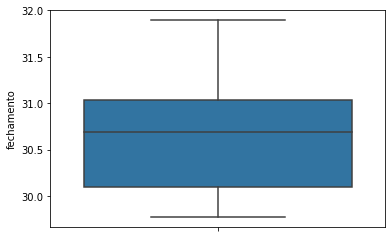

In [ ]:
dados = dados.loc[(dados["fechamento"]> 0 )]

sns.boxplot(y=dados["fechamento"])

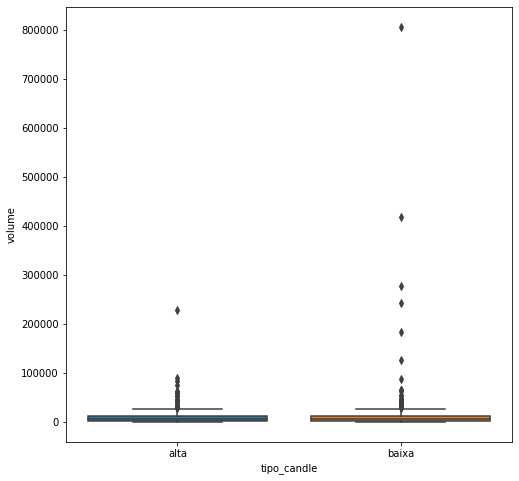

In [ ]:
plt.subplots(figsize=(8,8)) # Explicar como alterar o tamanho dos gráficos
sns.boxplot(y=dados["volume"],x = dados["tipo_candle"])
plt.show()

### (c) Scatter Plot

In [ ]:
dados1 = dados_itub.iloc[0:200]
dados2 = dados_petr.iloc[0:200]

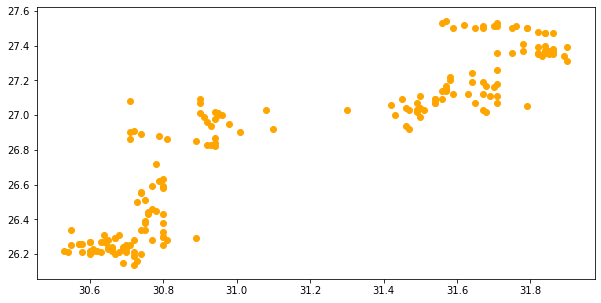

In [ ]:
plt.subplots(figsize=(10,5))

plt.scatter(dados1.open,dados2.open,c="orange")

plt.show()

### (d) Gráfico de linha

In [ ]:
dados.columns

Index(['timestamp', 'abertura', 'high', 'low', 'fechamento', 'volume', 'dif',
       'tipo_candle'],
      dtype='object')

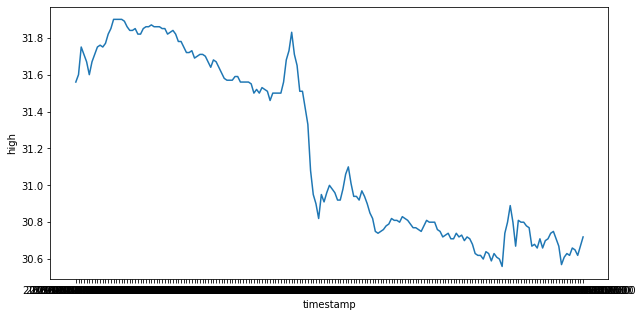

In [ ]:
plt.subplots(figsize=(10,5))

sns.lineplot(x="timestamp", y="high",
             data=dados1)

plt.show()

### (e) Grafico de correlação

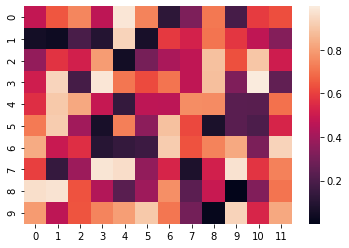

In [ ]:
uniform_data = np.random.rand(10, 12)
ax = sns.heatmap(uniform_data)

In [ ]:
dados.corr().round()

,abertura,high,low,fechamento,volume,dif
abertura,1.0,0.0,1.0,0.0,-0.0,1.0
high,0.0,1.0,0.0,1.0,-0.0,0.0
low,1.0,0.0,1.0,0.0,-0.0,1.0
fechamento,0.0,1.0,0.0,1.0,-0.0,0.0
volume,-0.0,-0.0,-0.0,-0.0,1.0,-0.0
dif,1.0,0.0,1.0,0.0,-0.0,1.0
